## Imports

In [1]:
import argparse
import torch

import seaborn as sns
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from scipy.ndimage import gaussian_filter1d

from src.datasets.smooth_signal_dataset import *
from src.losses.losses import *
from src.models.anchor_points_laplacian import AnchorPointsLaplacian

def save_combined_plots(non_uniform_x, f, uniform_x, f_uniform):
    """
    Creates one combined figure with two columns:
    Left Column (Non-Uniform):
        - The top self.hparams.k subplots: each eigenvector (with ylims [-0.15, 0.15])
        plotted versus non_uniform_x (line + scatter markers).
        - The bottom subplot: a heatmap of the dot-product matrix for non-uniform eigenvectors.
    Right Column (Uniform):
        - The top self.hparams.k subplots: each eigenvector (with ylims [-0.15, 0.15])
        plotted versus uniform_x (line + scatter markers).
        - The bottom subplot: a heatmap of the dot-product matrix for uniform eigenvectors.
    Additionally, titles are added above each column.
    """
    sns.set_style('whitegrid')

    num_eigen = 5           # Number of eigenvectors (and eigenvector subplots per block)
    num_rows = num_eigen + 1             # k rows for eigenvector plots + 1 row for the heatmap
    num_cols = 2                       # Left column: non-uniform, Right column: uniform

    # Determine x-axis limits for each case.
    x_min_non, x_max_non = np.min(non_uniform_x), np.max(non_uniform_x)
    x_min_uniform, x_max_uniform = np.min(uniform_x), np.max(uniform_x)

    # Set height ratios: give each eigenvector row a ratio of 1 and the heatmap a larger ratio (e.g., 3).
    height_ratios = [1] * num_eigen + [3]

    # Adjust overall figure size.
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols,
                            figsize=(18, (num_rows + 2) * 2),
                            gridspec_kw={'height_ratios': height_ratios})

    # --- Plot Eigenvectors ---
    for i in range(num_eigen):
        # Left Column: Non-uniform eigenvectors.
        ax_non = axes[i, 0]
        ax_non.plot(non_uniform_x, f[i], color=f'C{i}', label=f'Eigenvector {i+1}')
        ax_non.scatter(non_uniform_x, f[i], color='blue', s=10)
        ax_non.set_xlim(x_min_non, x_max_non)
        ax_non.set_ylim(-0.15, 0.15)
        ax_non.set_ylabel('Value', fontsize=10)
        ax_non.legend(fontsize=8)

        # Right Column: Uniform eigenvectors.
        ax_uniform = axes[i, 1]
        ax_uniform.plot(uniform_x, f_uniform[i], color=f'C{i}', label=f'Eigenvector {i+1}')
        ax_uniform.scatter(uniform_x, f_uniform[i], color='blue', s=10)
        ax_uniform.set_xlim(x_min_uniform, x_max_uniform)
        ax_uniform.set_ylim(-0.15, 0.15)
        ax_uniform.set_ylabel('Value', fontsize=10)
        ax_uniform.legend(fontsize=8)

    # --- Plot Dot-Product Heatmaps ---
    # Left Column: Non-uniform dot-product matrix.
    ax_heat_non = axes[num_eigen, 0]
    dot_non = np.dot(f, f.T)
    sns.heatmap(dot_non, annot=True, fmt=".2f", cmap='viridis',
                ax=ax_heat_non, square=True)
    ax_heat_non.set_title('Non-Uniform Dot-Product Matrix', fontsize=10)
    ax_heat_non.set_xlabel('Index', fontsize=10)
    ax_heat_non.set_ylabel('Index', fontsize=10)
    ax_heat_non.set_aspect('equal', adjustable='box')

    # Right Column: Uniform dot-product matrix.
    ax_heat_uniform = axes[num_eigen, 1]
    dot_uniform = np.dot(f_uniform, f_uniform.T)
    sns.heatmap(dot_uniform, annot=True, fmt=".2f", cmap='viridis',
                ax=ax_heat_uniform, square=True)
    ax_heat_uniform.set_title('Uniform Dot-Product Matrix', fontsize=10)
    ax_heat_uniform.set_xlabel('Index', fontsize=10)
    ax_heat_uniform.set_ylabel('Index', fontsize=10)
    ax_heat_uniform.set_aspect('equal', adjustable='box')

    # Adjust layout to make space for column titles.
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    # --- Add Column Titles ---
    # Use fig.text to add titles above each column.
    fig.text(0.25, 0.96, "Non-Uniform Sampling", ha='center', va='center', fontsize=16, weight='bold')
    fig.text(0.75, 0.96, "Uniform Sampling", ha='center', va='center', fontsize=16, weight='bold')

    # Save the figure to a temporary file.
    combined_filename = 'combined_plot.png'
    plt.show()

## Anchor Points Dataset

In [2]:
length = 100
signals_per_epoch = 1000
anchor_ratio = 0.5

ssd = SmoothSignalDataset(length, signals_per_epoch, anchor_ratio)

In [3]:
assert len(ssd) == signals_per_epoch

In [4]:
# anchor_points_x, samplings_x, manifold_y_at_anchor_points = apd[400]
manifold_y = ssd[300]
print(manifold_y.size())

torch.Size([2000])


## Anchor Points Laplacian

In [5]:
parser = argparse.ArgumentParser()
parser.add_argument('--name', type=str, default='test')
parser.add_argument('--signal_length', type=int, default=length)
parser.add_argument('--activation', type=str, default='relu')
parser.add_argument('--smoothing_sigma', type=float, default=100)
parser.add_argument('--k', type=int, default=5)
parser.add_argument('--signals_per_epoch', type=int, default=1000)
parser.add_argument('--hidden_dim', type=int, default=256)
parser.add_argument('--hidden_layers', type=int, default=3)
parser.add_argument('--max_epochs', type=int, default=100)
parser.add_argument('--num_workers', type=int, default=8)
parser.add_argument('--batch_size', type=int, default=64)
parser.add_argument('--lr', type=float, default=0.001)
parser.add_argument('--weight_decay', type=float, default=1e-4)

args = parser.parse_args([])


In [6]:
dl = DataLoader(ssd, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers)
apl = AnchorPointsLaplacian(args)

/home/arkadi.piven/miniconda3/envs/geometry/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


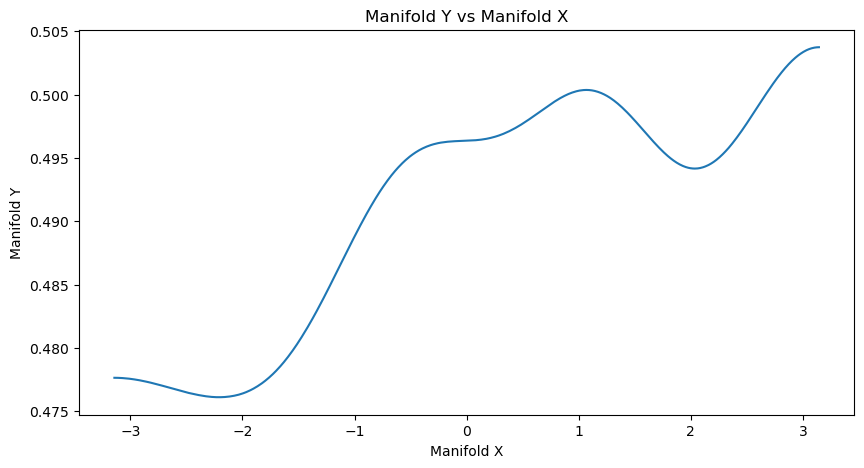

In [7]:
# Get one batch from the DataLoader
batch = next(iter(dl))
manifold_y = batch

manifold_y_to_plot = manifold_y[0].detach().numpy()
manifold_x = apl.manifold_x.detach().numpy()

plt.figure(figsize=(10, 5))
plt.plot(manifold_x, manifold_y_to_plot)
plt.xlabel('Manifold X')
plt.ylabel('Manifold Y')
plt.title('Manifold Y vs Manifold X')
plt.show()

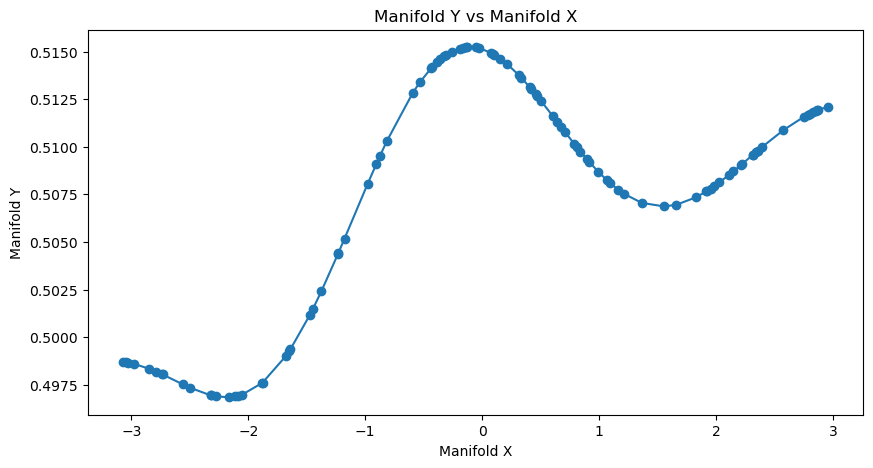

In [8]:
unsorted_indices = torch.randperm(apl.manifold_x.numel())[:args.signal_length]
sorted_indices, _ = torch.sort(unsorted_indices)

non_uniform_x = apl.manifold_x[sorted_indices].detach().numpy()
non_uniform_y = manifold_y[:, sorted_indices][50].detach().numpy()

plt.figure(figsize=(10, 5))
plt.plot(non_uniform_x, non_uniform_y, marker='o')
plt.xlabel('Manifold X')
plt.ylabel('Manifold Y')
plt.title('Manifold Y vs Manifold X')
plt.show()

In [9]:
ortho_loss = OrthonormalLoss()


unsorted_indices = torch.randperm(apl.manifold_x.numel())[:args.signal_length]
sorted_indices, _ = torch.sort(unsorted_indices)
linear_indices = torch.linspace(0, apl.manifold_x.numel() - 1, args.signal_length).long()

uniform_x = apl.manifold_x[linear_indices]
non_uniform_x = apl.manifold_x[sorted_indices]

f = apl(non_uniform_x)
f_uniform = apl(uniform_x)

f = f.reshape(args.k, args.signal_length)
f_uniform = f_uniform.reshape(args.k, args.signal_length)

print(ortho_loss(f, non_uniform_x))
print(ortho_loss(f_uniform, uniform_x))

f = f.detach().numpy()
f = f.reshape(args.k, args.signal_length)
non_uniform_x = non_uniform_x.detach().numpy().reshape(-1)



f_uniform = f_uniform.detach().numpy()
f_uniform = f_uniform.reshape(args.k, args.signal_length)
uniform_x = uniform_x.detach().numpy().reshape(-1)

save_combined_plots(non_uniform_x, f, uniform_x, f_uniform)


NameError: name 'OrthonormalLoss' is not defined

Polynomial order: 1
Coefficients [c0..c_order]: [ 1.4469537  -0.18713416]


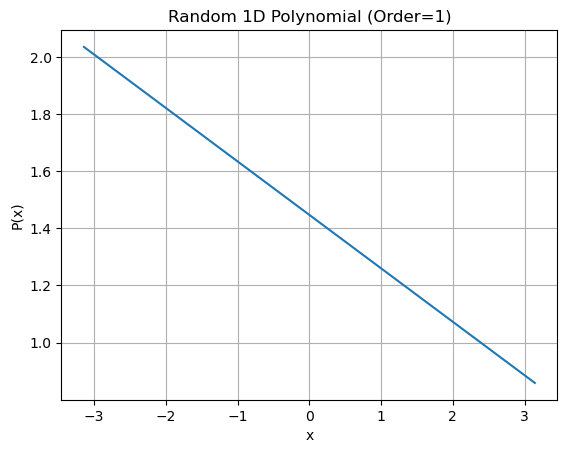

In [169]:
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum

class CoeffGenerationMethod(Enum):
    UNIFORM = "uniform"
    NORMAL = "normal"

def generate_polynomial_1D(
    order_range=(1, 5),
    coefficient_scale_range=(0.1, 1.0),
    coeff_generation_method=CoeffGenerationMethod.UNIFORM,
    seed=0
):
    """
    Generate a random 1D polynomial of randomly chosen order.

    Parameters
    ----------
    order_range : tuple (min_order, max_order)
        Inclusive range of polynomial orders.
    coefficient_scale_range : tuple (min_scale, max_scale)
        Range from which the scale factor for coefficients is drawn.
    coeff_generation_method : CoeffGenerationMethod
        Either UNIFORM or NORMAL for coefficient generation.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    order : int
        The chosen polynomial order.
    coeffs : np.ndarray
        1D array of polynomial coefficients [c0, c1, ..., c_order].
    polynomial_fn : callable
        A function that evaluates the polynomial at given x.
        For example, polynomial_fn(1.5) -> c0 + c1*(1.5) + c2*(1.5)^2 + ...
    """
    rng = np.random.default_rng()

    # 1) Pick the polynomial order
    order = rng.integers(low=order_range[0], high=order_range[1] + 1)

    # 2) Choose a random scale for the coefficients
    coefficient_scale = rng.uniform(
        low=coefficient_scale_range[0],
        high=coefficient_scale_range[1]
    )

    # 3) Generate coefficients using the selected method
    num_coeffs = order + 1
    if coeff_generation_method == CoeffGenerationMethod.UNIFORM:
        # Uniform in [-scale, +scale]
        coeffs_np = (2 * rng.random(num_coeffs) - 1.0) * coefficient_scale
    elif coeff_generation_method == CoeffGenerationMethod.NORMAL:
        # Normal with std = coefficient_scale
        coeffs_np = rng.normal(loc=0.0, scale=coefficient_scale, size=num_coeffs)
    else:
        raise ValueError(f"Invalid coefficient generation method: {coeff_generation_method}")

    # Convert to NumPy array of floats
    coeffs = np.array(coeffs_np, dtype=np.float32)

    # 4) Define a callable polynomial function
    #    P(x) = c0 + c1*x + c2*x^2 + ... + c_order*x^order
    def polynomial_fn(x):
        # x can be scalar or array-like. We'll rely on NumPy broadcasting.
        x = np.asarray(x, dtype=np.float32)
        # Evaluate using direct summation approach
        # y = c0 + c1*x + c2*x^2 + ... + c_order*x^order
        powers = np.array([x**i for i in range(order + 1)])
        if powers.ndim > 1:
            return np.sum(coeffs[..., None] * powers, axis=0)
        else:
            return np.sum(coeffs * powers)

    return order, coeffs, polynomial_fn

# ------------------------------------------------------------------------
# Example usage: Generate, evaluate, and plot the polynomial
# ------------------------------------------------------------------------
if __name__ == "__main__":
    order, coeffs, poly_fn = generate_polynomial_1D(
        order_range=(1, 5),            # from 1st to 5th degree
        coefficient_scale_range=(-3.0, 3.0),
        coeff_generation_method=CoeffGenerationMethod.UNIFORM,
    )

    print("Polynomial order:", order)
    print("Coefficients [c0..c_order]:", coeffs)

    # Sample the polynomial on a grid
    x_vals = np.linspace(-np.pi, np.pi, 20_000)
    y_vals = poly_fn(x_vals)

    # Plot
    plt.figure()
    plt.plot(x_vals, y_vals)
    plt.title(f"Random 1D Polynomial (Order={order})")
    plt.xlabel("x")
    plt.ylabel("P(x)")
    plt.grid(True)
    plt.show()
